In [ ]:
import zipfile
import os

with zipfile.ZipFile("northstar_dataset.zip", "r") as zip_ref:
    zip_ref.extractall("data")

print("DONE")
print(os.listdir("data"))

DONE
['northstar_dataset']


In [ ]:
import pandas as pd

path = "data/northstar_dataset/"

orders = pd.read_csv(path + "orders.csv")
deliveries = pd.read_csv(path + "deliveries.csv")
customers = pd.read_csv(path + "customers.csv")
drivers = pd.read_csv(path + "drivers.csv")
vehicles = pd.read_csv(path + "vehicles.csv")
hubs = pd.read_csv(path + "hubs.csv")
complaints = pd.read_csv(path + "complaints.csv")
incidents = pd.read_csv(path + "incidents.csv")
app_events = pd.read_csv(path + "app_events.csv")

print("PROJECT STARTED SUCCESSFULLY")

print("Orders:", orders.shape)
print("Deliveries:", deliveries.shape)
print("Customers:", customers.shape)
print("Drivers:", drivers.shape)
print("Vehicles:", vehicles.shape)
print("Hubs:", hubs.shape)
print("Complaints:", complaints.shape)
print("Incidents:", incidents.shape)
print("App Events:", app_events.shape)

PROJECT STARTED SUCCESSFULLY
Orders: (1250, 11)
Deliveries: (950, 13)
Customers: (650, 9)
Drivers: (170, 8)
Vehicles: (120, 8)
Hubs: (8, 5)
Complaints: (320, 10)
Incidents: (280, 7)
App Events: (640, 10)


In [ ]:
orders.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0


In [ ]:
print(orders.columns)

Index(['order_id', 'customer_id', 'service_type', 'order_created_at',
       'promised_window_hours', 'pickup_zone', 'dropoff_zone',
       'priority_level', 'order_value', 'booking_channel',
       'special_handling_flag'],
      dtype='object')


In [ ]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
service_type,0
order_created_at,0
promised_window_hours,0
pickup_zone,0
dropoff_zone,0
priority_level,0
order_value,0
booking_channel,25


In [ ]:
orders["booking_channel"] = orders["booking_channel"].fillna("Unknown")

print("Missing values after cleaning:")
print(orders.isnull().sum())

Missing values after cleaning:
order_id                 0
customer_id              0
service_type             0
order_created_at         0
promised_window_hours    0
pickup_zone              0
dropoff_zone             0
priority_level           0
order_value              0
booking_channel          0
special_handling_flag    0
dtype: int64


In [ ]:
service_counts = orders["service_type"].value_counts()

print(service_counts)

service_type
Passenger    341
Parcel       308
Retail       297
Business     165
Medical      139
Name: count, dtype: int64


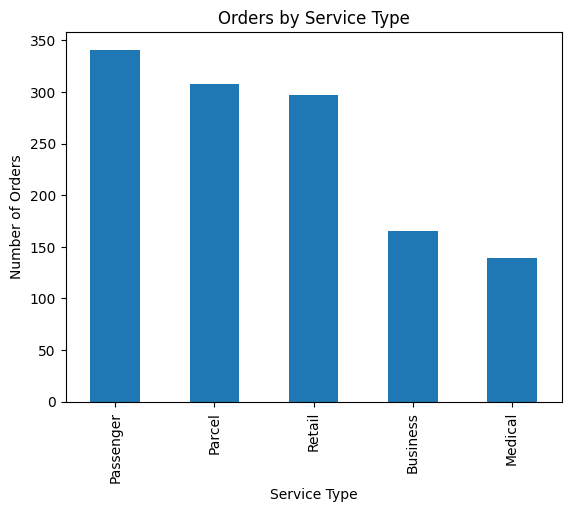

In [ ]:
import matplotlib.pyplot as plt

service_counts.plot(kind="bar")

plt.title("Orders by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Number of Orders")

plt.show()

In [ ]:
print(deliveries.columns)

Index(['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id',
       'dispatch_time', 'delivery_completed_at', 'delivery_status',
       'route_distance_km', 'manual_route_override_count',
       'proof_of_completion_missing', 'customer_rating_post_delivery',
       'fuel_or_charge_cost'],
      dtype='object')


In [ ]:
delivery_status = deliveries["delivery_status"].value_counts()

print(delivery_status)

delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64


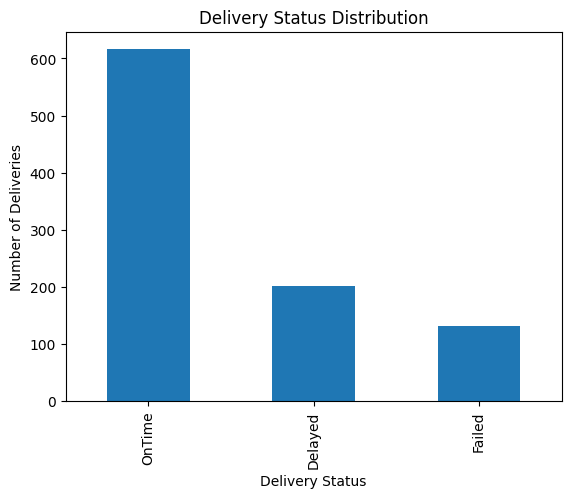

In [ ]:
import matplotlib.pyplot as plt

delivery_status.plot(kind="bar")

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Deliveries")

plt.show()

In [ ]:
override_analysis = deliveries.groupby(
    "manual_route_override_count"
)["delivery_status"].value_counts().unstack().fillna(0)

print(override_analysis)

delivery_status              Delayed  Failed  OnTime
manual_route_override_count                         
0                               78.0    46.0   275.0
1                               67.0    51.0   192.0
2                               34.0    22.0    97.0
3                               14.0    10.0    33.0
4                                5.0     3.0    15.0
5                                4.0     0.0     3.0
7                                0.0     0.0     1.0


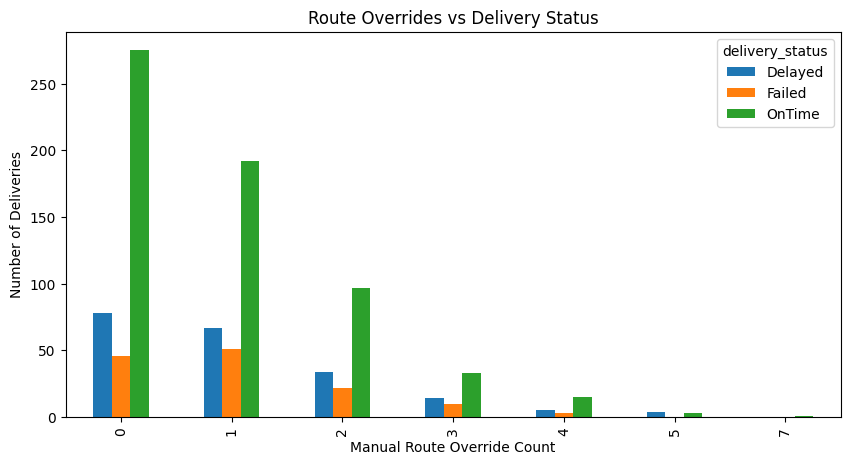

In [ ]:
override_analysis.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Route Overrides vs Delivery Status")
plt.xlabel("Manual Route Override Count")
plt.ylabel("Number of Deliveries")

plt.show()

In [ ]:
master = deliveries.merge(
    orders[["order_id", "pickup_zone"]],
    on="order_id",
    how="left"
)

print(master.head())

  delivery_id order_id driver_id vehicle_id hub_id        dispatch_time  \
0     DL00001   O00938      D004       V056    H05  2024-06-18 10:57:00   
1     DL00002   O00004      D138       V007    H02  2025-01-11 18:45:00   
2     DL00003   O00639      D006       V049    H02  2025-06-02 20:39:00   
3     DL00004   O00313      D116       V055    H02  2024-03-08 23:31:00   
4     DL00005   O00844      D108       V034    H01  2025-09-21 11:43:00   

        delivery_completed_at delivery_status  route_distance_km  \
0  2024-06-19 09:05:59.904311          Failed              17.26   
1  2025-01-11 17:39:00.000000          OnTime              10.34   
2  2025-06-02 21:45:32.366770          OnTime               7.92   
3  2024-03-09 23:30:08.103702         Delayed              16.42   
4  2025-09-21 15:45:34.131056          OnTime              14.52   

   manual_route_override_count  proof_of_completion_missing  \
0                            1                            0   
1             

In [ ]:
cost_by_zone = master.groupby(
    "pickup_zone"
)["fuel_or_charge_cost"].mean().sort_values(
    ascending=False
)

print(cost_by_zone)

pickup_zone
AIRPORT      17.406087
Airport      16.852537
RiverSide    13.198485
EAST         13.001154
South        12.732771
North        12.371351
north        12.360385
CENTRAL      12.159455
Central      12.142909
East         12.132949
West         12.114314
SOUTH        12.109643
Ctr          12.067344
WEST         11.790476
NORTH        11.505652
Riverside    11.388679
Name: fuel_or_charge_cost, dtype: float64


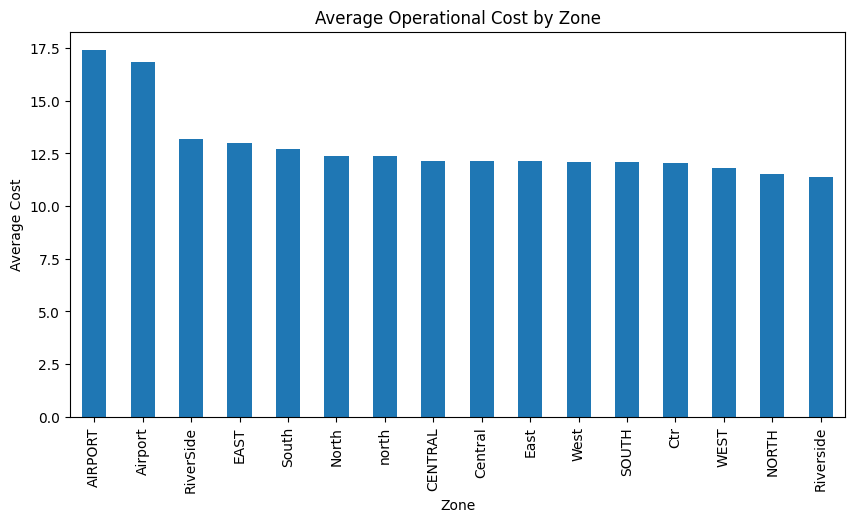

In [ ]:
cost_by_zone.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Operational Cost by Zone")
plt.xlabel("Zone")
plt.ylabel("Average Cost")

plt.show()

In [ ]:
print(complaints.columns)

Index(['complaint_id', 'customer_id', 'order_id', 'complaint_type', 'channel',
       'severity', 'created_at', 'status', 'resolution_days',
       'compensation_amount'],
      dtype='object')


In [ ]:
complaint_counts = complaints["complaint_type"].value_counts()

print(complaint_counts)

complaint_type
Delay                101
MissedPickup          64
AppIssue              53
DriverBehaviour       51
SupportExperience     20
Billing               16
Damage                15
Name: count, dtype: int64


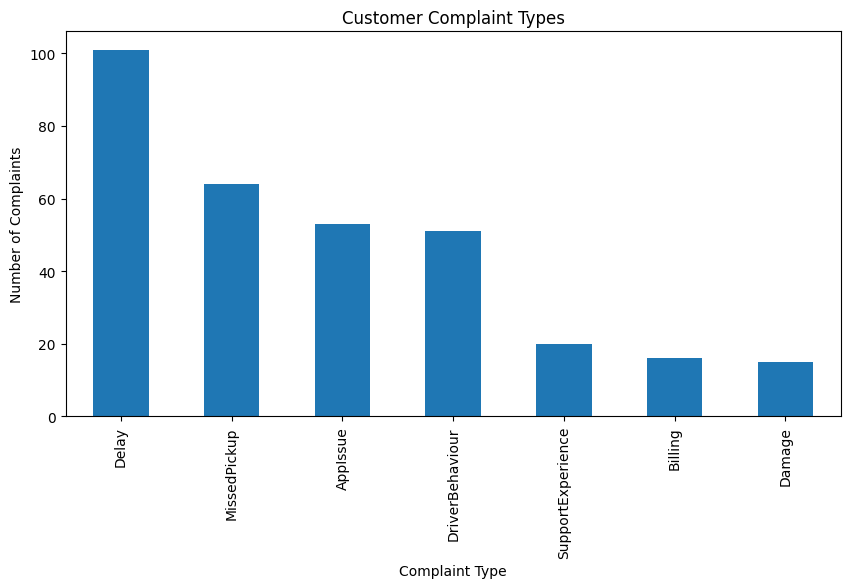

In [ ]:
complaint_counts.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Customer Complaint Types")
plt.xlabel("Complaint Type")
plt.ylabel("Number of Complaints")

plt.show()

In [ ]:
severity_counts = complaints["severity"].value_counts()

print(severity_counts)

severity
Medium    172
High       77
Low        71
Name: count, dtype: int64


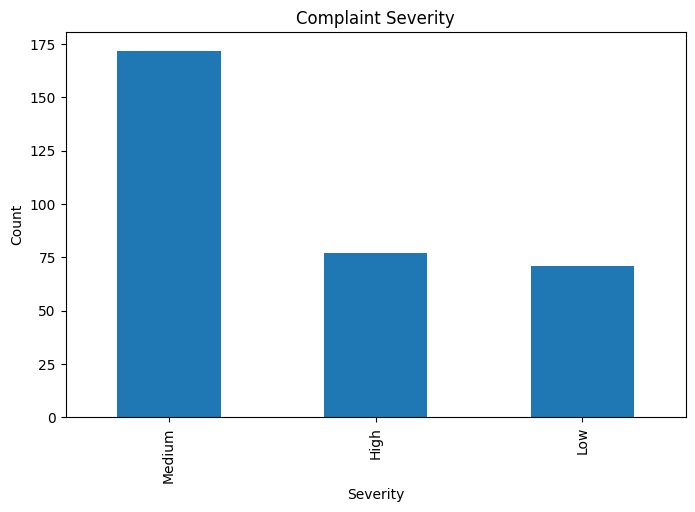

In [ ]:
severity_counts.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Complaint Severity")
plt.xlabel("Severity")
plt.ylabel("Count")

plt.show()

In [ ]:
complaint_delivery = complaints.merge(
    deliveries[["order_id", "delivery_status"]],
    on="order_id",
    how="left"
)

print(complaint_delivery.head())

  complaint_id customer_id order_id complaint_type  channel severity  \
0       CP0001       C0464   O00814       AppIssue      App     High   
1       CP0002       C0056   O00628   MissedPickup    Phone   Medium   
2       CP0003       C0469   O00384          Delay  Chatbot     High   
3       CP0004       C0631   O00406          Delay      App   Medium   
4       CP0005       C0535   O00154          Delay    Email   Medium   

            created_at            status  resolution_days  \
0  2025-03-30 02:36:00              Open               11   
1  2024-11-07 10:05:00              Open                4   
2  2024-01-02 15:47:00              Open               16   
3  2025-01-14 13:07:00  AwaitingCustomer                7   
4  2024-08-31 05:56:00          Resolved                1   

   compensation_amount delivery_status  
0                23.99          OnTime  
1                21.64         Delayed  
2                26.41         Delayed  
3                23.44          OnTi

In [ ]:
complaints_by_status = complaint_delivery[
    "delivery_status"
].value_counts()

print(complaints_by_status)

delivery_status
OnTime     149
Delayed     48
Failed      35
Name: count, dtype: int64


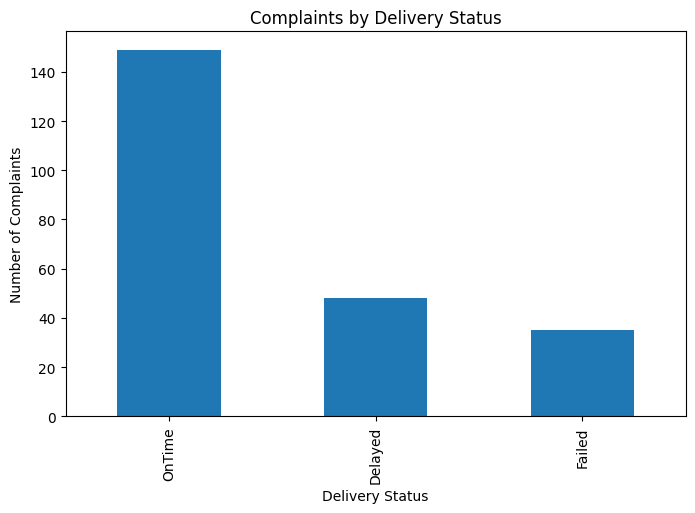

In [ ]:
complaints_by_status.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Complaints by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Complaints")

plt.show()